# LIANA split analysis: PLA vs platelet-free

- `PLA` subset: cells with `pla_status == "PLA"`
- `platelet-free` subset: cells with missing/platelet-free `pla_status`
- Cell groups used by LIANA: `lineage`

## 1. Libraries and paths

In [1]:
suppressPackageStartupMessages({
  library(Seurat)
  library(liana)
  library(dplyr)
  library(tidyr)
  library(tibble)
  library(stringr)
  library(purrr)
  library(ggplot2)
  library(forcats)
  library(circlize)
})

set.seed(123)

# "gated_ImmuneAging.rds", "gated_heart_processed.rds", "gated_sepsis_processed.rds", "gated_vaccine_processed.rds", "gated_our_dataset_processed.rds"
#file_name <- "gated_ImmuneAging.rds"
#file_name <- "gated_heart_processed.rds" 
file_name <- "gated_sepsis_processed.rds" 
#file_name <- "gated_vaccine_processed.rds" 
#file_name <- "gated_our_dataset_processed.rds" 

input_file <- "/nfs/home/students/i.kaciran/FoPra_PLAs/data//datasets/gated_sepsis_processed.rds"
out_dir <- "/nfs/home/students/i.kaciran/FoPra_PLAs/results/cell_signaling/liana_split_pla_vs_platelet_free"
plot_dir <- file.path(out_dir, "plots")

dir.create(out_dir, recursive = TRUE, showWarnings = FALSE)
dir.create(plot_dir, recursive = TRUE, showWarnings = FALSE)

message("Output directory: ", out_dir)

Output directory: /nfs/home/students/i.kaciran/FoPra_PLAs/results/cell_signaling/liana_split_pla_vs_platelet_free



## 2. Load and prepare Seurat object

In [2]:
seurat_obj <- readRDS(input_file)

DefaultAssay(seurat_obj)
ncol(seurat_obj)
nrow(seurat_obj)
colnames(seurat_obj@meta.data)

[1] "RNA"

[1] 285043

[1] 37487

[1] "orig.ident"                             
 [2] "nCount_RNA"                             
 [3] "nFeature_RNA"                           
 [4] "nCount_ADT"                             
 [5] "nFeature_ADT"                           
 [6] "sample"                                 
 [7] "donor_id"                               
 [8] "cell_barcodes"                          
 [9] "scRNA.seq"                              
[10] "TCR"                                    
[11] "BCR"                                    
[12] "CITE.seq"                               
[13] "Bulk.RNA.seq"                           
[14] "Olink.proteomics"                       
[15] "Gender"                                 
[16] "Age"                                    
[17] "Sample.Collection.Date"                 
[18] "Sample.Collection.Site"                 
[19] "Group"                                  
[20] "Sepsis.Infection.Source"                
[21] "Ethnicity"                              
[22] "Chronic.comorbidity.None"               
[23] "Cardiovascular.compromise"              
[24] "COPD"                                   
[25] "Hypertension"                           
[26] "Diabetes"                               
[27] "Respiratory.insufficiency"              
[28] "Renal.insufficiency"                    
[29] "Tuberculosis"                           
[30] "Length.of.ICU.stay.days"                
[31] "Length.of.hospital.stay.days"           
[32] "X14.day.mortality..Deceased.1.Living.0."
[33] "X28.day.mortality..Deceased.1.Living.0."
[34] "X90.day.mortality..Deceased.1.Living.0."
[35] "Gram.positive.bacteria"                 
[36] "Gram.negative.bacteria"                 
[37] "Virus"                                  
[38] "Fungi"                                  
[39] "Microbiology.laboratory..Unknown"       
[40] "SOFA.score"                             
[41] "Shock"                                  
[42] "Organ.failure"                          
[43] "Mechanical.ventilation"                 
[44] "percent.mt"                             
[45] "percent.ribo"                           
[46] "percent.hb"                             
[47] "mt_outlier_all"                         
[48] "is_outlier_RNA"                         
[49] "is_outlier_protein"                     
[50] "is_outlier"                             
[51] "scDblFinder.class"                      
[52] "scDblFinder.score"                      
[53] "RNA_snn_res.0.8"                        
[54] "seurat_clusters"                        
[55] "RNA_snn_res.0.25"                       
[56] "RNA.weight"                             
[57] "ADT.weight"                             
[58] "leiden_0.8_totalVI"                     
[59] "leiden_0.25_totalVI"                    
[60] "celltype_full"                          
[61] "lineage"                                
[62] "pla_status"                             
[63] "celltype"

In [5]:
# required metadata columns
required_cols <- c("pla_status", "lineage")
missing_cols <- setdiff(required_cols, colnames(seurat_obj@meta.data))

if (length(missing_cols) > 0) {
  stop("Missing required metadata columns: ", paste(missing_cols, collapse = ", "))
}

# define missing PLA status as platelet-free
seurat_obj$pla_status[is.na(seurat_obj$pla_status)] <- "platelet-free"

# remove missing and uninterpretable lineages
seurat_obj <- subset(
  seurat_obj,
  subset = !is.na(lineage) & lineage != "Unassigned"
)

# Optional: remove lineages that are only present in one condition.
seurat_obj <- subset(
  seurat_obj,
  subset = lineage != "neutrophils"
)

# Keep original readable names for plotting.
seurat_obj$lineage <- as.character(seurat_obj$lineage)
seurat_obj$pla_status <- as.character(seurat_obj$pla_status)

table(seurat_obj$pla_status, useNA = "ifany")
table(seurat_obj$lineage, seurat_obj$pla_status, useNA = "ifany")


          PLA platelet-free 
        39405        123924 

             
                PLA platelet-free
  B cells       488         20788
  CD4 T cells  5680         45049
  CD8 T cells  7504         19400
  DCs          2298          3440
  Monocytes   20992          3479
  NK cells     2443         31768

## 3. Split into PLA and platelet-free subsets

In [6]:
seurat_pla <- subset(seurat_obj, subset = pla_status == "PLA")
seurat_pf  <- subset(seurat_obj, subset = pla_status == "platelet-free")

# LIANA should infer communication between lineages, so identities are lineage.
Idents(seurat_pla) <- "lineage"
Idents(seurat_pf)  <- "lineage"

message("PLA cells: ", ncol(seurat_pla))
print(table(Idents(seurat_pla)))

message("platelet-free cells: ", ncol(seurat_pf))
print(table(Idents(seurat_pf)))

PLA cells: 39405




CD8 T cells CD4 T cells   Monocytes    NK cells         DCs     B cells 
       7504        5680       20992        2443        2298         488 


platelet-free cells: 123924




    B cells CD4 T cells    NK cells         DCs   Monocytes CD8 T cells 
      20788       45049       31768        3440        3479       19400 


In [7]:
set.seed(123)

liana_pla_raw <- liana_wrap(seurat_pla)

liana_pla <- liana_pla_raw %>%
  liana_aggregate() %>%
  arrange(aggregate_rank)

saveRDS(liana_pla_raw, file.path(out_dir, "PLA_liana_raw.rds"))
write.csv(liana_pla, file.path(out_dir, "PLA_liana_consensus.csv"), row.names = FALSE)

Expression from the `RNA` assay will be used

Running LIANA with `colLabels`/`Idents` as labels (matching column in metadata not found).

Warning message:
“The `slot` argument of `GetAssayData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.
ℹ The deprecated feature was likely used in the liana package.
  Please report the issue at <https://github.com/saezlab/liana/issues>.”
Warning message in exec(output, ...):
“12546 genes and/or 0 cells were removed as they had no counts!”
Warning message:
“`invoke()` is deprecated as of rlang 0.4.0.
Please use `exec()` or `inject()` instead.
This warning is displayed once every 8 hours.”
LIANA: LR summary stats calculated!

Now Running: Natmi

Now Running: Connectome

Now Running: Logfc

Now Running: Sca

Now Running: Cellphonedb

Warning message:
“`progress_estimated()` was deprecated in dplyr 1.0.0.
ℹ The deprecated feature was likely used in the liana package.
  Please report the issue at <https://github.com/

In [8]:
set.seed(123)

liana_pf_raw <- liana_wrap(seurat_pf)

liana_pf <- liana_pf_raw %>%
  liana_aggregate() %>%
  arrange(aggregate_rank)

saveRDS(liana_pf_raw, file.path(out_dir, "platelet_free_liana_raw.rds"))
write.csv(liana_pf, file.path(out_dir, "platelet_free_liana_consensus.csv"), row.names = FALSE)

Expression from the `RNA` assay will be used

Running LIANA with `colLabels`/`Idents` as labels (matching column in metadata not found).

Warning message in exec(output, ...):
“10460 genes and/or 0 cells were removed as they had no counts!”
Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 1.5 GiB”
Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 1.5 GiB”
LIANA: LR summary stats calculated!

Now Running: Natmi

Now Running: Connectome

Now Running: Logfc

Now Running: Sca

Now Running: Cellphonedb

Now aggregating natmi

Now aggregating connectome

Now aggregating logfc

Now aggregating sca

Now aggregating cellphonedb

Aggregating Ranks



In [9]:
rank_threshold <- 0.01

pla_sig <- liana_pla %>%
  filter(!is.na(aggregate_rank), aggregate_rank <= rank_threshold)

pf_sig <- liana_pf %>%
  filter(!is.na(aggregate_rank), aggregate_rank <= rank_threshold)

In [10]:
pla_st <- pla_sig %>%
  count(source, target, name = "n_PLA")

pf_st <- pf_sig %>%
  count(source, target, name = "n_platelet_free")

source_target_compare <- full_join(
  pla_st,
  pf_st,
  by = c("source", "target")
) %>%
  mutate(
    n_PLA = ifelse(is.na(n_PLA), 0, n_PLA),
    n_platelet_free = ifelse(is.na(n_platelet_free), 0, n_platelet_free),
    difference = n_PLA - n_platelet_free
  )

head(source_target_compare)

source,target,n_PLA,n_platelet_free,difference
<chr>,<chr>,<int>,<dbl>,<dbl>
B cells,B cells,6,3,3
B cells,CD4 T cells,12,1,11
B cells,CD8 T cells,35,0,35
B cells,DCs,15,2,13
B cells,Monocytes,10,5,5
B cells,NK cells,14,0,14


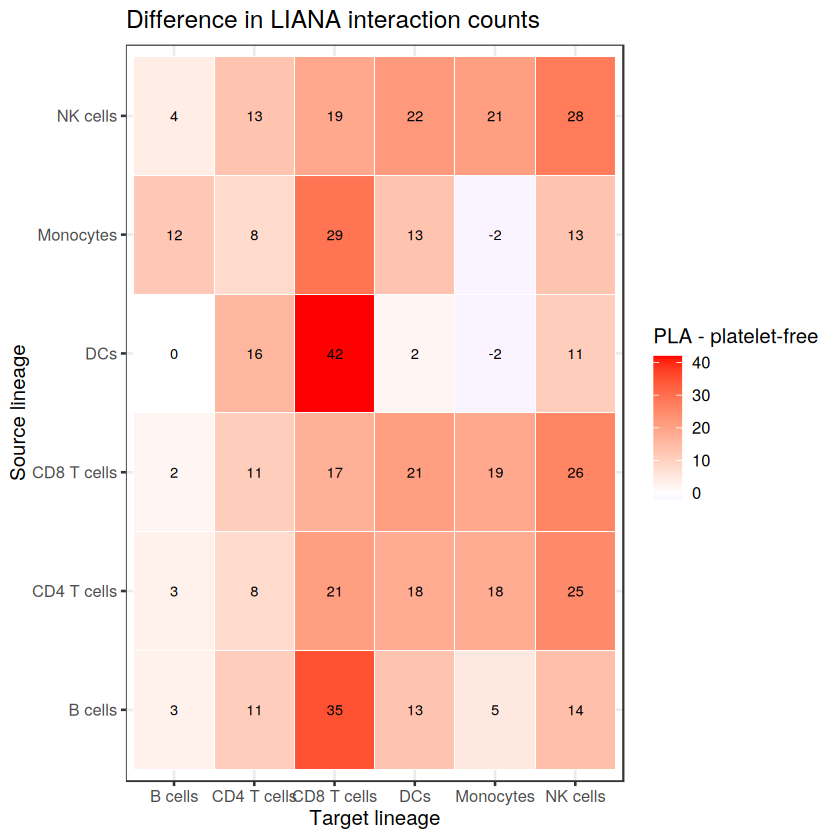

In [11]:
p_st_diff <- ggplot(source_target_compare, aes(
  x = target,
  y = source,
  fill = difference
)) +
  geom_tile(color = "white") +
  geom_text(aes(label = difference), size = 3) +
  scale_fill_gradient2(
    low = "blue",
    mid = "white",
    high = "red",
    midpoint = 0
  ) +
  theme_bw(base_size = 12) +
  labs(
    x = "Target lineage",
    y = "Source lineage",
    fill = "PLA - platelet-free",
    title = "Difference in LIANA interaction counts"
  )

p_st_diff

ggsave(
  file.path(out_dir, "liana_split_source_target_difference_heatmap.png"),
  p_st_diff,
  width = 8,
  height = 6,
  dpi = 300
)

In [12]:
pla_lr <- pla_sig %>%
  mutate(lr_pair = paste(ligand.complex, receptor.complex, sep = " -> ")) %>%
  count(lr_pair, name = "n_PLA")

pf_lr <- pf_sig %>%
  mutate(lr_pair = paste(ligand.complex, receptor.complex, sep = " -> ")) %>%
  count(lr_pair, name = "n_platelet_free")

lr_compare <- full_join(pla_lr, pf_lr, by = "lr_pair") %>%
  mutate(
    n_PLA = ifelse(is.na(n_PLA), 0, n_PLA),
    n_platelet_free = ifelse(is.na(n_platelet_free), 0, n_platelet_free),
    difference = n_PLA - n_platelet_free,
    category = case_when(
      n_PLA > 0 & n_platelet_free > 0 ~ "shared",
      n_PLA > 0 & n_platelet_free == 0 ~ "PLA-only",
      n_PLA == 0 & n_platelet_free > 0 ~ "platelet-free-only"
    )
  )

count(lr_compare, category)

category,n
<chr>,<int>
PLA-only,113
platelet-free-only,9
shared,55


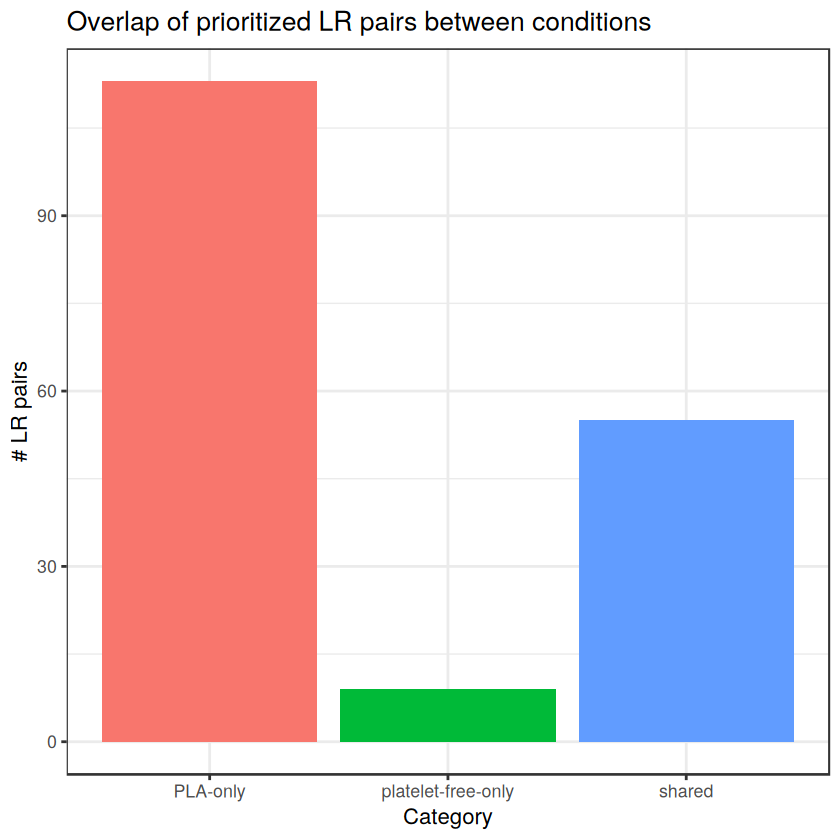

In [13]:
p_lr_category <- lr_compare %>%
  count(category) %>%
  ggplot(aes(x = category, y = n, fill = category)) +
  geom_col() +
  theme_bw(base_size = 13) +
  labs(
    x = "Category",
    y = "# LR pairs",
    title = "Overlap of prioritized LR pairs between conditions"
  ) +
  theme(legend.position = "none")

p_lr_category

ggsave(
  file.path(out_dir, "liana_split_lr_pair_overlap.png"),
  p_lr_category,
  width = 6,
  height = 5,
  dpi = 300
)

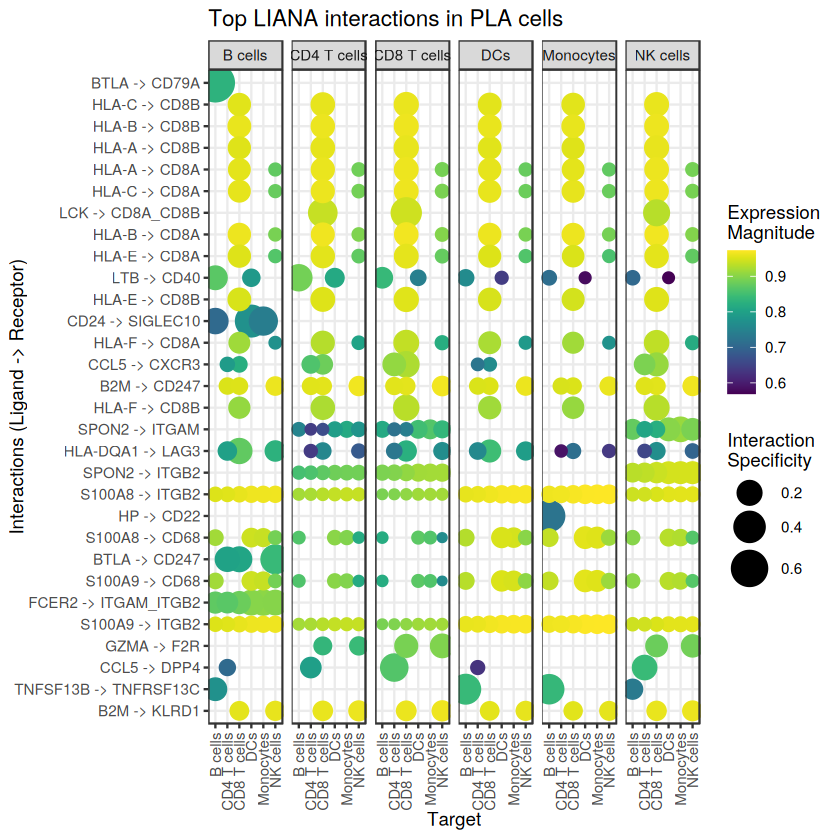

In [14]:
p_pla_dot <- liana_pla %>%
  arrange(aggregate_rank) %>%
  liana_dotplot(ntop = 30, show_complex = TRUE) +
  theme_bw(base_size = 11) +
  theme(axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5)) +
  ggtitle("Top LIANA interactions in PLA cells")

p_pla_dot

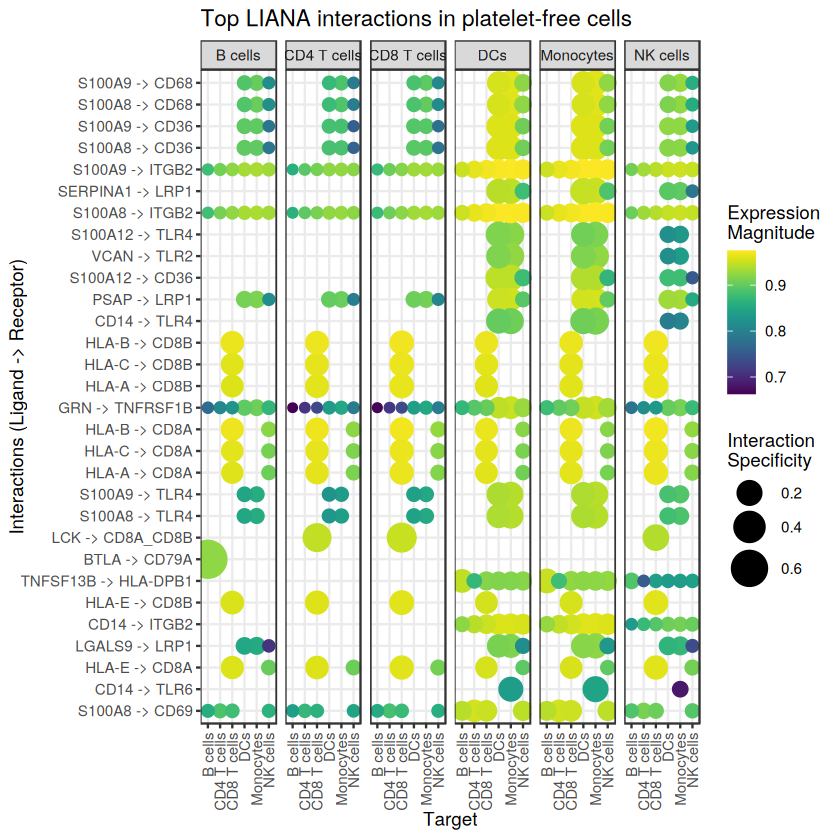

In [15]:
p_pf_dot <- liana_pf %>%
  arrange(aggregate_rank) %>%
  liana_dotplot(ntop = 30, show_complex = TRUE) +
  theme_bw(base_size = 11) +
  theme(axis.text.x = element_text(angle = 90, hjust = 1, vjust = 0.5)) +
  ggtitle("Top LIANA interactions in platelet-free cells")

p_pf_dot

In [16]:
ggsave(
  file.path(out_dir, "liana_split_PLA_dotplot_top30.png"),
  p_pla_dot,
  width = 12,
  height = 8,
  dpi = 300
)

ggsave(
  file.path(out_dir, "liana_split_platelet_free_dotplot_top30.png"),
  p_pf_dot,
  width = 12,
  height = 8,
  dpi = 300
)

In [17]:
thresholds <- c(0.005, 0.01, 0.02, 0.05)

threshold_summary <- lapply(thresholds, function(thr) {
  pla_sig <- liana_pla %>%
    filter(!is.na(aggregate_rank), aggregate_rank <= thr) %>%
    mutate(lr_pair = paste(ligand.complex, receptor.complex, sep = " -> "))

  pf_sig <- liana_pf %>%
    filter(!is.na(aggregate_rank), aggregate_rank <= thr) %>%
    mutate(lr_pair = paste(ligand.complex, receptor.complex, sep = " -> "))

  pla_pairs <- unique(pla_sig$lr_pair)
  pf_pairs <- unique(pf_sig$lr_pair)

  tibble(
    threshold = thr,
    PLA_only = length(setdiff(pla_pairs, pf_pairs)),
    platelet_free_only = length(setdiff(pf_pairs, pla_pairs)),
    shared = length(intersect(pla_pairs, pf_pairs)),
    n_PLA_total = length(pla_pairs),
    n_platelet_free_total = length(pf_pairs)
  )
}) %>%
  bind_rows()

threshold_summary

threshold,PLA_only,platelet_free_only,shared,n_PLA_total,n_platelet_free_total
<dbl>,<int>,<int>,<int>,<int>,<int>
0.005,53,17,30,83,47
0.010,113,9,55,168,64
0.020,115,15,76,191,91
0.050,43,18,185,228,203


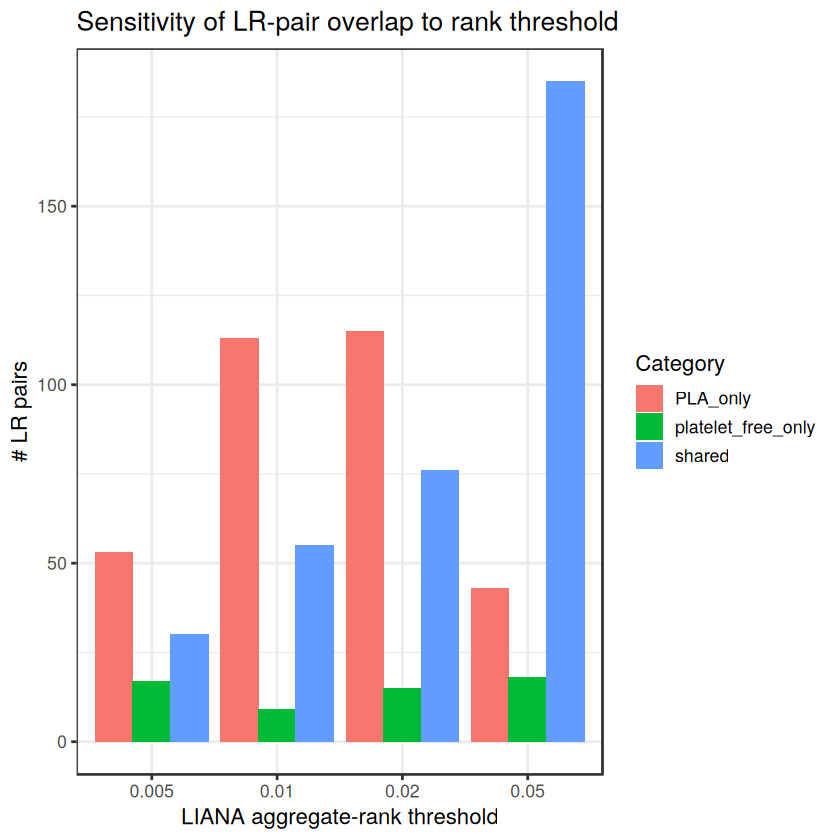

In [18]:
p_threshold <- threshold_summary %>%
  tidyr::pivot_longer(
    cols = c(PLA_only, platelet_free_only, shared),
    names_to = "category",
    values_to = "n_lr_pairs"
  ) %>%
  ggplot(aes(
    x = factor(threshold),
    y = n_lr_pairs,
    fill = category
  )) +
  geom_col(position = "dodge") +
  theme_bw(base_size = 13) +
  labs(
    x = "LIANA aggregate-rank threshold",
    y = "# LR pairs",
    fill = "Category",
    title = "Sensitivity of LR-pair overlap to rank threshold"
  )

p_threshold